# 02 Toast Correlations

Toast POS is the baseline. This notebook builds a daily demand table, then walks through the strongest calendar and weather relationships we can detect in the current 2026-to-date dataset.

With roughly four months, treat correlations as discovery signals. They tell us what to investigate and eventually model, not what caused demand.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT / 'notebooks' / 'lib'))

import pantry_eda as eda

pd = eda.pd
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)

sales = eda.read_pos_item_selections()
weather = eda.read_weather_daily(year=2026)

sales.shape, weather.shape

/Users/shepardberry/CodexProjects/Pantry/notebooks/lib/pantry_eda.py:164: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw["timestamp"] = pd.to_datetime(raw["date"], errors="coerce")
/Users/shepardberry/CodexProjects/Pantry/notebooks/lib/pantry_eda.py:165: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw["business_date"] = raw["timestamp"].dt.date


((50137, 17), (124, 27))

## 1. Build the Daily Baseline

The baseline is one row per business day with total quantity, orders, net sales, category quantities, and simple per-order metrics.

In [2]:
daily_sales = eda.daily_sales(sales)
daily_categories = eda.daily_category_sales(sales)

daily = daily_sales.merge(daily_categories, on='business_date', how='left')
daily['avg_qty_per_order'] = daily['qty'] / daily['orders']
daily['avg_net_sales_per_order'] = daily['net_sales'] / daily['orders']
daily['date'] = pd.to_datetime(daily['business_date'])
daily['weekday'] = daily['date'].dt.day_name()
daily['weekday_num'] = daily['date'].dt.weekday
daily['month'] = daily['date'].dt.month_name()
daily['is_weekend'] = daily['weekday_num'].isin([4, 5, 6])

daily.head()

,business_date,qty,net_sales,orders,qty_beer,qty_food,qty_liquor,qty_na_beverage,qty_wine_sake,avg_qty_per_order,avg_net_sales_per_order,date,weekday,weekday_num,month,is_weekend
0,2026-01-02,568.0,5684.0,35,6.0,478.0,42.0,17.0,25.0,16.228571,162.400000,2026-01-02,Friday,4,January,True
1,2026-01-03,572.0,5729.0,33,6.0,490.0,50.0,16.0,10.0,17.333333,173.606061,2026-01-03,Saturday,5,January,True
2,2026-01-04,461.0,4824.4,29,6.0,401.0,35.0,7.0,12.0,15.896552,166.358621,2026-01-04,Sunday,6,January,True
3,2026-01-05,525.0,4839.0,28,7.0,452.0,26.0,20.0,20.0,18.750000,172.821429,2026-01-05,Monday,0,January,False
4,2026-01-06,508.0,5570.6,30,7.0,423.0,47.0,13.0,18.0,16.933333,185.686667,2026-01-06,Tuesday,1,January,False


## 1A. Longer Product Mix Export Check

The Jan-Apr Product Mix export gives us longer-range category/menu mix, but the current files are aggregate report tables without a date column. That means they cannot directly replace the daily Toast baseline for weather or day-of-week correlations.

Use this section to confirm what the longer export contains. For daily correlations across Jan-Apr, we need a Product Mix export broken out by day, or an Item Selection Details export for Jan 1-Apr 30.

In [3]:
product_mix = eda.read_product_mix_export()
product_mix_summary = pd.DataFrame([
    {
        'file': name,
        'rows': len(frame),
        'columns': frame.shape[1],
        'has_daily_granularity': eda.product_mix_has_daily_granularity(frame),
    }
    for name, frame in product_mix.items()
])
product_mix_summary

""


In [4]:
all_levels = product_mix.get('All levels.csv')
all_levels

In [5]:
pd.DataFrame([{
    'days': daily['business_date'].nunique(),
    'date_min': daily['business_date'].min(),
    'date_max': daily['business_date'].max(),
    'total_qty': daily['qty'].sum(),
    'total_orders': daily['orders'].sum(),
    'net_sales': daily['net_sales'].sum(),
    'avg_daily_qty': daily['qty'].mean(),
    'avg_daily_orders': daily['orders'].mean(),
}])

,days,date_min,date_max,total_qty,total_orders,net_sales,avg_daily_qty,avg_daily_orders
0,118,2026-01-02,2026-04-30,52900.0,3730,595029.78,448.305085,31.610169


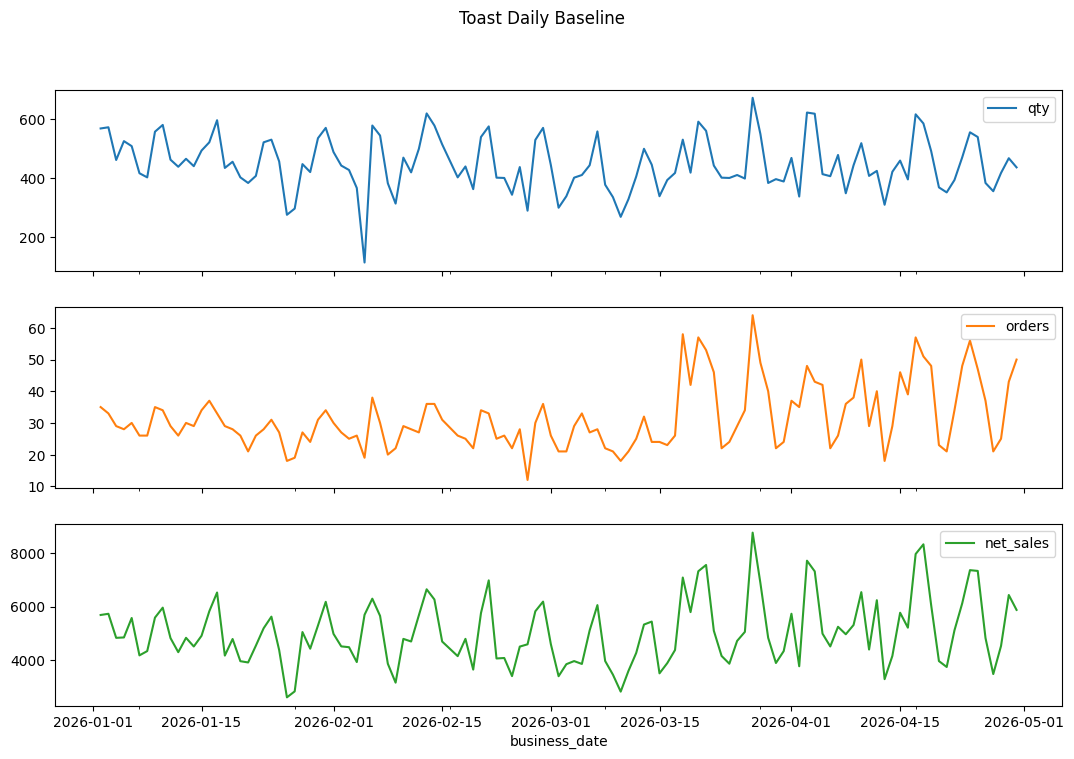

In [6]:
daily.set_index('business_date')[['qty', 'orders', 'net_sales']].plot(subplots=True, figsize=(13, 8), title='Toast Daily Baseline');

## 2. Day-of-Week Effects

Calendar effects are the clearest signal in this sample. Since weekday is categorical, we inspect both daily means and one-hot indicator correlations.

In [7]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_summary = (
    daily.groupby('weekday', as_index=False)
    .agg(
        days=('business_date', 'nunique'),
        avg_qty=('qty', 'mean'),
        avg_orders=('orders', 'mean'),
        avg_net_sales=('net_sales', 'mean'),
        avg_food_qty=('qty_food', 'mean'),
        avg_liquor_qty=('qty_liquor', 'mean'),
    )
)
weekday_summary['weekday'] = pd.Categorical(weekday_summary['weekday'], categories=weekday_order, ordered=True)
weekday_summary = weekday_summary.sort_values('weekday')
weekday_summary

,weekday,days,avg_qty,avg_orders,avg_net_sales,avg_food_qty,avg_liquor_qty
1,Monday,16,381.875000,23.000000,3880.876250,326.062500,27.937500
5,Tuesday,17,399.411765,24.764706,4160.825294,338.764706,28.764706
6,Wednesday,17,420.647059,31.941176,4871.428824,353.764706,28.470588
4,Thursday,17,393.941176,31.411765,4879.796471,326.176471,34.000000
0,Friday,17,557.823529,40.882353,6367.178235,469.294118,47.000000
2,Saturday,17,551.529412,36.705882,6378.624118,464.000000,48.058824
3,Sunday,17,429.000000,32.058824,4691.309412,376.058824,25.647059


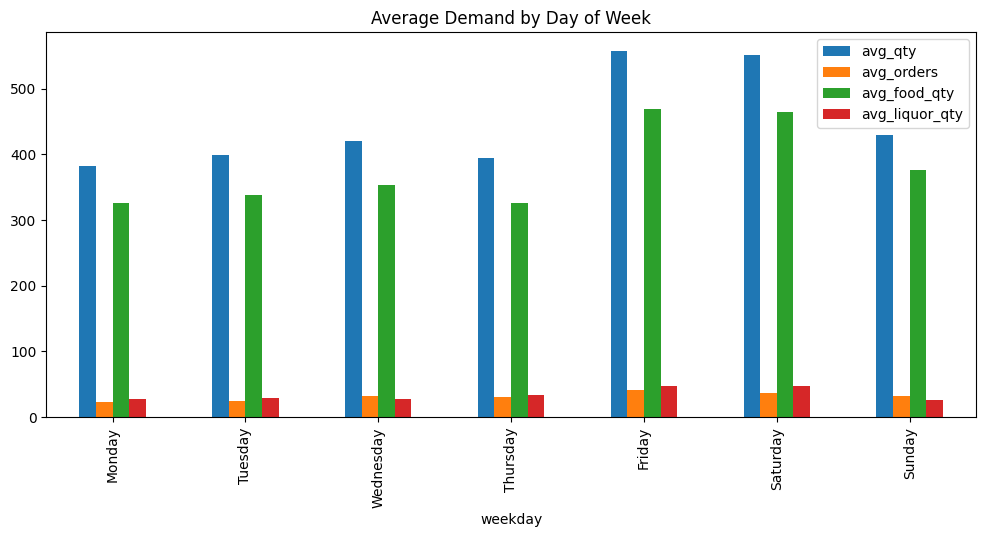

In [8]:
weekday_summary.plot(x='weekday', y=['avg_qty', 'avg_orders', 'avg_food_qty', 'avg_liquor_qty'], kind='bar', figsize=(12, 5), title='Average Demand by Day of Week');

In [9]:
demand_cols = [
    'qty',
    'orders',
    'net_sales',
    'avg_qty_per_order',
    'avg_net_sales_per_order',
] + [column for column in daily.columns if column.startswith('qty_')]

weekday_dummies = pd.get_dummies(daily['weekday'], prefix='weekday').astype(int)
weekday_corr = pd.concat([daily[demand_cols], weekday_dummies], axis=1).corr(numeric_only=True).loc[demand_cols, weekday_dummies.columns]
ranked_weekday = weekday_corr.stack().reset_index().rename(columns={'level_0': 'demand_metric', 'level_1': 'weekday_metric', 0: 'correlation'})
ranked_weekday['abs_correlation'] = ranked_weekday['correlation'].abs()
ranked_weekday.sort_values('abs_correlation', ascending=False).head(25)

,demand_metric,weekday_metric,correlation,abs_correlation
0,qty,weekday_Friday,0.489945,0.489945
51,qty_liquor,weekday_Saturday,0.469039,0.469039
42,qty_food,weekday_Friday,0.462526,0.462526
2,qty,weekday_Saturday,0.461788,0.461788
16,net_sales,weekday_Saturday,0.444411,0.444411
14,net_sales,weekday_Friday,0.440603,0.440603
44,qty_food,weekday_Saturday,0.435223,0.435223
49,qty_liquor,weekday_Friday,0.432886,0.432886
7,orders,weekday_Friday,0.377503,0.377503
15,net_sales,weekday_Monday,-0.373067,0.373067


### Current Read

In the current Jan-Apr export, Friday is the clearest positive volume signal. Monday is the clearest negative order-count signal, although average quantity per order is high on Monday because there are fewer orders. Saturday lifts liquor quantity.

## 3. Month Effects

Month is not a pure external factor, but it helps surface seasonality and operating changes across Jan-Apr.

In [10]:
month_summary = (
    daily.groupby('month', as_index=False)
    .agg(
        days=('business_date', 'nunique'),
        avg_qty=('qty', 'mean'),
        avg_orders=('orders', 'mean'),
        avg_net_sales=('net_sales', 'mean'),
        avg_food_qty=('qty_food', 'mean'),
        avg_liquor_qty=('qty_liquor', 'mean'),
    )
    .sort_values('avg_qty', ascending=False)
)
month_summary

,month,days,avg_qty,avg_orders,avg_net_sales,avg_food_qty,avg_liquor_qty
2,January,30,471.166667,28.766667,4838.761000,400.300000,36.166667
0,April,30,449.733333,37.966667,5539.106667,380.333333,35.833333
1,February,27,445.814815,27.518519,4930.168889,375.148148,34.333333
3,March,31,426.967742,31.774194,4857.393226,362.774194,31.064516


In [11]:
month_dummies = pd.get_dummies(daily['month'], prefix='month').astype(int)
month_corr = pd.concat([daily[demand_cols], month_dummies], axis=1).corr(numeric_only=True).loc[demand_cols, month_dummies.columns]
ranked_month = month_corr.stack().reset_index().rename(columns={'level_0': 'demand_metric', 'level_1': 'month_metric', 0: 'correlation'})
ranked_month['abs_correlation'] = ranked_month['correlation'].abs()
ranked_month.sort_values('abs_correlation', ascending=False).head(25)

,demand_metric,month_metric,correlation,abs_correlation
12,avg_qty_per_order,month_April,-0.449351,0.449351
4,orders,month_April,0.368309,0.368309
17,avg_net_sales_per_order,month_February,0.322483,0.322483
14,avg_qty_per_order,month_January,0.295612,0.295612
16,avg_net_sales_per_order,month_April,-0.264068,0.264068
13,avg_qty_per_order,month_February,0.250459,0.250459
8,net_sales,month_April,0.235037,0.235037
5,orders,month_February,-0.221174,0.221174
21,qty_beer,month_February,0.177696,0.177696
6,orders,month_January,-0.164759,0.164759


### Current Read

April shows more orders and lower average quantity per order than earlier months. January has the highest average daily quantity, while March is lower on both quantity and liquor.

## 4. Weather Join

The weather export has granular rows plus daily summary rows. The loader filters 2026 daily rows and standardizes temperature to Fahrenheit, precipitation/snow to inches, and wind to mph.

In [12]:
joined = daily.merge(weather, on='business_date', how='inner')
joined['had_precipitation'] = joined['daily_precipitation_in'].fillna(0).gt(0)
joined['had_snowfall'] = joined.get('daily_snowfall_in', 0).fillna(0).gt(0)
joined['temperature_range_f'] = joined['daily_maximum_dry_bulb_temperature_f'] - joined['daily_minimum_dry_bulb_temperature_f']

joined[['business_date', 'qty', 'orders', 'net_sales', 'daily_average_dry_bulb_temperature_f', 'daily_precipitation_in', 'daily_average_wind_speed_mph', 'daily_average_relative_humidity']].head()

,business_date,qty,orders,net_sales,daily_average_dry_bulb_temperature_f,daily_precipitation_in,daily_average_wind_speed_mph,daily_average_relative_humidity
0,2026-01-02,568.0,35,5684.0,21.02,0.0,7.16,58.500000
1,2026-01-03,572.0,33,5729.0,23.00,0.0,5.37,49.300000
2,2026-01-04,461.0,29,4824.4,27.50,0.0,8.95,53.750000
3,2026-01-05,525.0,28,4839.0,38.48,0.0,7.61,71.937500
4,2026-01-06,508.0,30,5570.6,39.56,0.0,7.16,86.735294


In [13]:
pd.DataFrame([{
    'toast_days': daily['business_date'].nunique(),
    'weather_days': weather['business_date'].nunique(),
    'joined_days': joined['business_date'].nunique(),
    'joined_start': joined['business_date'].min(),
    'joined_end': joined['business_date'].max(),
}])

,toast_days,weather_days,joined_days,joined_start,joined_end
0,118,124,118,2026-01-02,2026-04-30


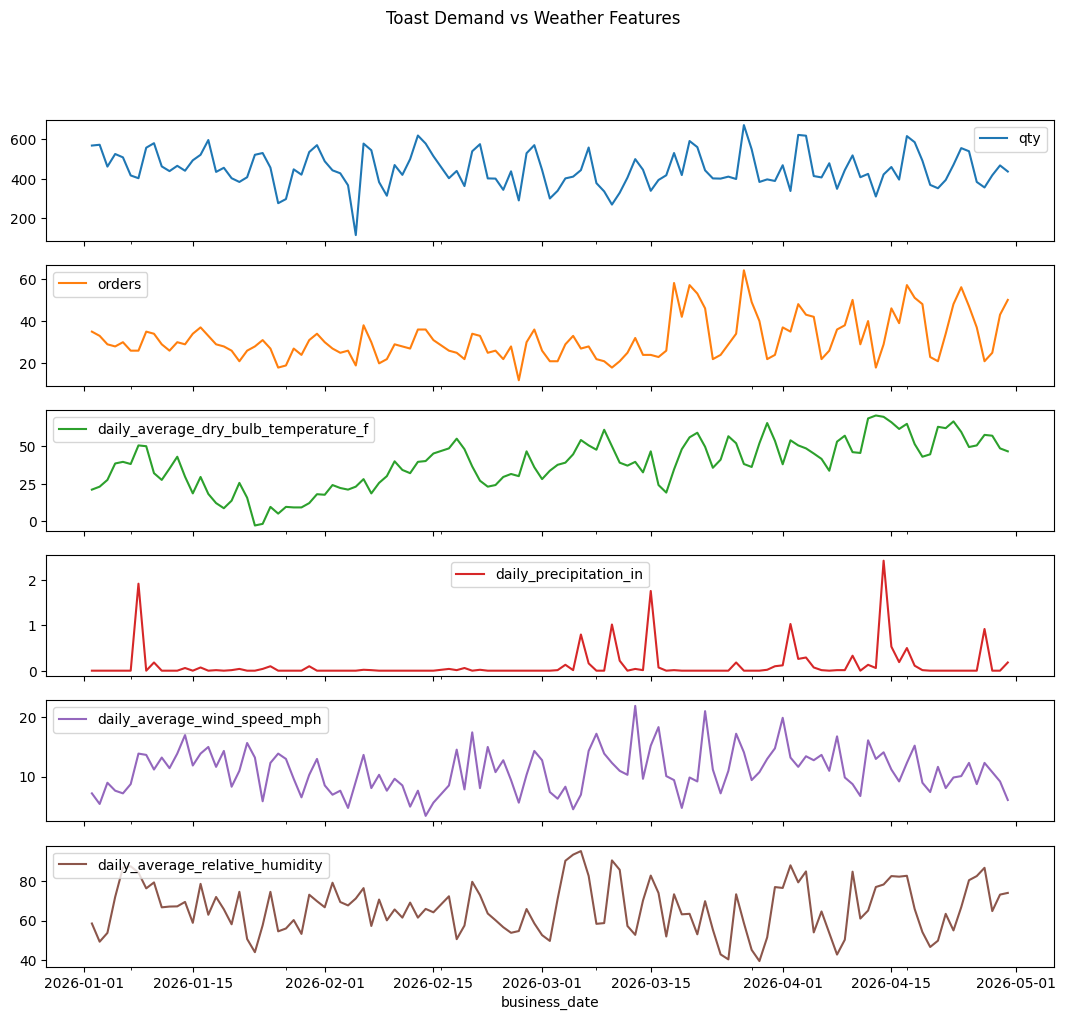

In [14]:
trend_cols = [
    'qty',
    'orders',
    'daily_average_dry_bulb_temperature_f',
    'daily_precipitation_in',
    'daily_average_wind_speed_mph',
    'daily_average_relative_humidity',
]
joined.set_index('business_date')[trend_cols].plot(subplots=True, figsize=(13, 11), title='Toast Demand vs Weather Features');

## 5. Weather Correlations

These are Pearson correlations between daily Toast demand metrics and daily weather features.

In [15]:
weather_cols = [
    'daily_maximum_dry_bulb_temperature_f',
    'daily_minimum_dry_bulb_temperature_f',
    'daily_average_dry_bulb_temperature_f',
    'temperature_range_f',
    'daily_precipitation_in',
    'daily_snowfall_in',
    'daily_snow_depth_in',
    'daily_average_wind_speed_mph',
    'daily_sustained_wind_speed_mph',
    'daily_peak_wind_speed_mph',
    'daily_average_relative_humidity',
    'daily_average_dew_point_temperature_f',
]
weather_cols = [column for column in weather_cols if column in joined.columns]

weather_corr = joined[demand_cols + weather_cols].corr(numeric_only=True).loc[demand_cols, weather_cols]
ranked_weather = weather_corr.stack().reset_index().rename(columns={'level_0': 'demand_metric', 'level_1': 'weather_metric', 0: 'correlation'})
ranked_weather['abs_correlation'] = ranked_weather['correlation'].abs()
ranked_weather.sort_values('abs_correlation', ascending=False).head(30)

,demand_metric,weather_metric,correlation,abs_correlation
36,avg_qty_per_order,daily_maximum_dry_bulb_temperature_f,-0.418363,0.418363
38,avg_qty_per_order,daily_average_dry_bulb_temperature_f,-0.405039,0.405039
47,avg_qty_per_order,daily_average_dew_point_temperature_f,-0.383515,0.383515
37,avg_qty_per_order,daily_minimum_dry_bulb_temperature_f,-0.370958,0.370958
12,orders,daily_maximum_dry_bulb_temperature_f,0.327675,0.327675
39,avg_qty_per_order,temperature_range_f,-0.321649,0.321649
14,orders,daily_average_dry_bulb_temperature_f,0.314717,0.314717
23,orders,daily_average_dew_point_temperature_f,0.293211,0.293211
13,orders,daily_minimum_dry_bulb_temperature_f,0.284704,0.284704
48,avg_net_sales_per_order,daily_maximum_dry_bulb_temperature_f,-0.266192,0.266192


### Current Read

The strongest weather relationship currently found is average quantity per order vs temperature. Warmer days are associated with more orders but fewer items per order, which may point to a shift in party/order composition rather than a simple total-sales lift.

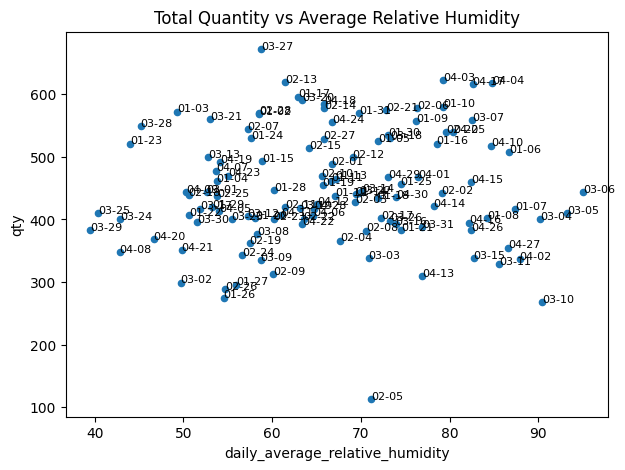

In [16]:
axes = joined.plot(kind='scatter', x='daily_average_relative_humidity', y='qty', figsize=(7, 5), title='Total Quantity vs Average Relative Humidity')
for _, row in joined.iterrows():
    axes.annotate(str(row['business_date'])[-5:], (row['daily_average_relative_humidity'], row['qty']), fontsize=8);

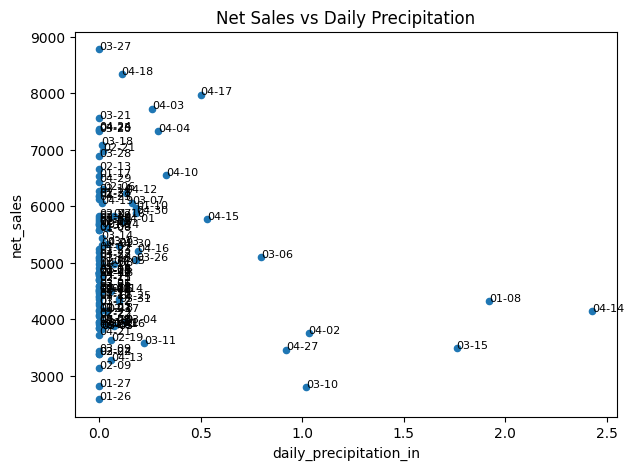

In [17]:
axes = joined.plot(kind='scatter', x='daily_precipitation_in', y='net_sales', figsize=(7, 5), title='Net Sales vs Daily Precipitation')
for _, row in joined.iterrows():
    axes.annotate(str(row['business_date'])[-5:], (row['daily_precipitation_in'], row['net_sales']), fontsize=8);

## 6. Rain vs No Rain

This is easier to reason about than continuous precipitation correlation. It groups days by whether measurable precipitation occurred.

In [18]:
rain_summary = (
    joined.groupby('had_precipitation', as_index=False)
    .agg(
        days=('business_date', 'nunique'),
        avg_qty=('qty', 'mean'),
        avg_orders=('orders', 'mean'),
        avg_net_sales=('net_sales', 'mean'),
        avg_food_qty=('qty_food', 'mean'),
        avg_liquor_qty=('qty_liquor', 'mean'),
        avg_beer_qty=('qty_beer', 'mean'),
    )
)
rain_summary

,had_precipitation,days,avg_qty,avg_orders,avg_net_sales,avg_food_qty,avg_liquor_qty,avg_beer_qty
0,False,68,448.823529,30.838235,5012.892794,380.338235,33.264706,7.470588
1,True,50,447.600000,32.660000,5083.061400,378.620000,35.760000,6.480000


## 7. Category Mix Sensitivity

A factor may shift what sells even when total demand barely moves. Here we inspect category quantities and category share correlations.

In [19]:
category_cols = [column for column in joined.columns if column.startswith('qty_')]
mix = joined[['business_date', 'qty'] + category_cols + weather_cols].copy()
for column in category_cols:
    mix[f'{column}_share'] = mix[column] / mix['qty']

share_cols = [column for column in mix.columns if column.endswith('_share')]
share_corr = mix[share_cols + weather_cols].corr(numeric_only=True).loc[share_cols, weather_cols]
ranked_share = share_corr.stack().reset_index().rename(columns={'level_0': 'category_share_metric', 'level_1': 'weather_metric', 0: 'correlation'})
ranked_share['abs_correlation'] = ranked_share['correlation'].abs()
ranked_share.sort_values('abs_correlation', ascending=False).head(25)

,category_share_metric,weather_metric,correlation,abs_correlation
42,qty_na_beverage_share,daily_snow_depth_in,0.249342,0.249342
6,qty_beer_share,daily_snow_depth_in,0.182182,0.182182
36,qty_na_beverage_share,daily_maximum_dry_bulb_temperature_f,-0.181678,0.181678
38,qty_na_beverage_share,daily_average_dry_bulb_temperature_f,-0.169657,0.169657
18,qty_food_share,daily_snow_depth_in,-0.168564,0.168564
39,qty_na_beverage_share,temperature_range_f,-0.167695,0.167695
37,qty_na_beverage_share,daily_minimum_dry_bulb_temperature_f,-0.146305,0.146305
47,qty_na_beverage_share,daily_average_dew_point_temperature_f,-0.145674,0.145674
7,qty_beer_share,daily_average_wind_speed_mph,-0.127156,0.127156
19,qty_food_share,daily_average_wind_speed_mph,0.122298,0.122298


## 8. Top Item Weather Sensitivity

This searches for high-volume items that move more strongly with weather than the overall restaurant. These are candidates for feature engineering or manual review.

In [20]:
top_item_names = eda.top_items(sales, n=25)['menu_item'].tolist()
item_daily = (
    sales[sales['menu_item'].isin(top_item_names)]
    .pivot_table(index='business_date', columns='menu_item', values='qty', aggfunc='sum', fill_value=0)
    .reset_index()
)
item_weather = item_daily.merge(weather, on='business_date', how='inner')
item_weather['temperature_range_f'] = item_weather['daily_maximum_dry_bulb_temperature_f'] - item_weather['daily_minimum_dry_bulb_temperature_f']

item_corr = item_weather[top_item_names + weather_cols].corr(numeric_only=True).loc[top_item_names, weather_cols]
ranked_item_weather = item_corr.stack().reset_index().rename(columns={'level_0': 'menu_item', 'level_1': 'weather_metric', 0: 'correlation'})
ranked_item_weather['abs_correlation'] = ranked_item_weather['correlation'].abs()
ranked_item_weather.sort_values('abs_correlation', ascending=False).head(30)

,menu_item,weather_metric,correlation,abs_correlation
230,Chef Series: Cá Ngân,daily_average_dry_bulb_temperature_f,-0.493123,0.493123
229,Chef Series: Cá Ngân,daily_minimum_dry_bulb_temperature_f,-0.484318,0.484318
228,Chef Series: Cá Ngân,daily_maximum_dry_bulb_temperature_f,-0.483695,0.483695
239,Chef Series: Cá Ngân,daily_average_dew_point_temperature_f,-0.415272,0.415272
234,Chef Series: Cá Ngân,daily_snow_depth_in,0.354564,0.354564
50,Bay Scallop Dynamite,daily_average_dry_bulb_temperature_f,-0.297926,0.297926
48,Bay Scallop Dynamite,daily_maximum_dry_bulb_temperature_f,-0.296796,0.296796
49,Bay Scallop Dynamite,daily_minimum_dry_bulb_temperature_f,-0.287424,0.287424
233,Chef Series: Cá Ngân,daily_snowfall_in,0.281104,0.281104
59,Bay Scallop Dynamite,daily_average_dew_point_temperature_f,-0.269752,0.269752


### Current Read

The strongest item-level weather signals in this sample include Chef Series: Cá Ngân and Bay Scallop Dynamite moving negatively with temperature. Item-level signals are still noisier than total/category metrics, so treat these as candidates for follow-up.

## 9. Multivariable Correlations and Interactions

Pairwise correlations miss combined effects. This section fits small interpretable linear models with standardized features and interaction terms like Friday x warm day or Saturday x precipitation day.

Read `standardized_coefficient` as directional effect size after putting features on comparable scales. It is not a causal estimate, but it helps rank which combined factors deserve attention.

In [21]:
import numpy as np

multi = joined.copy()
multi['is_friday'] = multi['weekday'].eq('Friday').astype(int)
multi['is_saturday'] = multi['weekday'].eq('Saturday').astype(int)
multi['is_sunday'] = multi['weekday'].eq('Sunday').astype(int)
multi['is_april'] = multi['month'].eq('April').astype(int)
multi['is_precip_day'] = multi['daily_precipitation_in'].fillna(0).gt(0).astype(int)
multi['warm_day'] = (multi['daily_maximum_dry_bulb_temperature_f'] >= multi['daily_maximum_dry_bulb_temperature_f'].median()).astype(int)
multi['windy_day'] = (multi['daily_average_wind_speed_mph'] >= multi['daily_average_wind_speed_mph'].median()).astype(int)

base_features = [
    'daily_maximum_dry_bulb_temperature_f',
    'daily_precipitation_in',
    'daily_average_wind_speed_mph',
    'daily_average_relative_humidity',
    'is_friday',
    'is_saturday',
    'is_sunday',
    'is_april',
    'is_precip_day',
    'warm_day',
    'windy_day',
]
interaction_pairs = [
    ('is_friday', 'warm_day'),
    ('is_saturday', 'warm_day'),
    ('is_sunday', 'warm_day'),
    ('is_friday', 'is_precip_day'),
    ('is_saturday', 'is_precip_day'),
    ('is_sunday', 'is_precip_day'),
    ('is_friday', 'windy_day'),
    ('is_saturday', 'windy_day'),
    ('is_april', 'warm_day'),
    ('is_april', 'is_precip_day'),
]

feature_cols = list(base_features)
for left, right in interaction_pairs:
    name = f'{left}_x_{right}'
    multi[name] = multi[left] * multi[right]
    feature_cols.append(name)

targets = ['qty', 'orders', 'net_sales', 'avg_qty_per_order']
effect_rows = []
score_rows = []
for target in targets:
    model_frame = multi[[target] + feature_cols].dropna()
    X = model_frame[feature_cols].astype(float)
    y = model_frame[target].astype(float)
    X_scaled = (X - X.mean()) / X.std(ddof=0).replace(0, 1)
    design = np.column_stack([np.ones(len(X_scaled)), X_scaled.to_numpy()])
    coefficients, *_ = np.linalg.lstsq(design, y.to_numpy(), rcond=None)
    predictions = design @ coefficients
    residual = y.to_numpy() - predictions
    sse = float((residual ** 2).sum())
    sst = float(((y.to_numpy() - y.mean()) ** 2).sum())
    r_squared = 1 - (sse / sst) if sst else 0
    adjusted_r_squared = 1 - ((1 - r_squared) * (len(y) - 1) / max(len(y) - len(feature_cols) - 1, 1))
    score_rows.append({'target': target, 'rows': len(y), 'features': len(feature_cols), 'r_squared': r_squared, 'adjusted_r_squared': adjusted_r_squared})
    for feature, coefficient in zip(feature_cols, coefficients[1:]):
        effect_rows.append({
            'target': target,
            'feature': feature,
            'standardized_coefficient': coefficient,
            'abs_standardized_coefficient': abs(coefficient),
            'feature_type': 'interaction' if '_x_' in feature else 'main_effect',
        })

multivariable_effects = pd.DataFrame(effect_rows).sort_values('abs_standardized_coefficient', ascending=False)
multivariable_scores = pd.DataFrame(score_rows).sort_values('adjusted_r_squared', ascending=False)
multivariable_scores

,target,rows,features,r_squared,adjusted_r_squared
2,net_sales,118,21,0.647195,0.570019
0,qty,118,21,0.620581,0.537584
1,orders,118,21,0.510633,0.403583
3,avg_qty_per_order,118,21,0.389155,0.255533


In [22]:
multivariable_effects.head(30)

,target,feature,standardized_coefficient,abs_standardized_coefficient,feature_type
47,net_sales,is_saturday,498.690297,498.690297,main_effect
49,net_sales,is_april,493.887446,493.887446,main_effect
61,net_sales,is_april_x_warm_day,-480.617303,480.617303,interaction
46,net_sales,is_friday,439.917815,439.917815,main_effect
52,net_sales,windy_day,-338.760156,338.760156,main_effect
62,net_sales,is_april_x_is_precip_day,288.165281,288.165281,interaction
59,net_sales,is_friday_x_windy_day,227.087319,227.087319,interaction
42,net_sales,daily_maximum_dry_bulb_temperature_f,219.472766,219.472766,main_effect
60,net_sales,is_saturday_x_windy_day,218.409124,218.409124,interaction
50,net_sales,is_precip_day,-191.940497,191.940497,main_effect


In [23]:
multivariable_effects[multivariable_effects['feature_type'].eq('interaction')].head(30)

,target,feature,standardized_coefficient,abs_standardized_coefficient,feature_type
61,net_sales,is_april_x_warm_day,-480.617303,480.617303,interaction
62,net_sales,is_april_x_is_precip_day,288.165281,288.165281,interaction
59,net_sales,is_friday_x_windy_day,227.087319,227.087319,interaction
60,net_sales,is_saturday_x_windy_day,218.409124,218.409124,interaction
58,net_sales,is_sunday_x_is_precip_day,140.552079,140.552079,interaction
53,net_sales,is_friday_x_warm_day,86.530827,86.530827,interaction
57,net_sales,is_saturday_x_is_precip_day,84.719668,84.719668,interaction
55,net_sales,is_sunday_x_warm_day,-63.644827,63.644827,interaction
19,qty,is_april_x_warm_day,-46.730361,46.730361,interaction
54,net_sales,is_saturday_x_warm_day,22.917709,22.917709,interaction


### Current Read

The multivariable model is intentionally simple and interpretable. Use it to identify interaction candidates, then validate them with more data or proper forecasting backtests before trusting them for purchasing decisions.

## 10. Export Correlation Tables

In [ ]:
outputs = PROJECT_ROOT / 'notebooks' / 'outputs'
outputs.mkdir(exist_ok=True)

joined.to_csv(outputs / 'daily_toast_correlation_base_2026_to_date.csv', index=False)
ranked_weekday.sort_values('abs_correlation', ascending=False).to_csv(outputs / 'ranked_weekday_correlations_2026_to_date.csv', index=False)
ranked_month.sort_values('abs_correlation', ascending=False).to_csv(outputs / 'ranked_month_correlations_2026_to_date.csv', index=False)
ranked_weather.sort_values('abs_correlation', ascending=False).to_csv(outputs / 'ranked_weather_correlations_2026_to_date.csv', index=False)
ranked_share.sort_values('abs_correlation', ascending=False).to_csv(outputs / 'ranked_category_share_weather_correlations_2026_to_date.csv', index=False)
ranked_item_weather.sort_values('abs_correlation', ascending=False).to_csv(outputs / 'ranked_item_weather_correlations_2026_to_date.csv', index=False)
multivariable_effects.to_csv(outputs / 'ranked_multivariable_effects_2026_to_date.csv', index=False)
multivariable_scores.to_csv(outputs / 'multivariable_model_scores_2026_to_date.csv', index=False)

print('Wrote correlation outputs to', outputs)